# IGBT RUL Prediction — 12 Model Comparison

## Feature Design Rationale
Time proxies (`TimeEpoch`, `HeatsinkTemp`, `Transient_Block_ID`) are **excluded** from features.
- `TimeEpoch` and `Transient_Block_ID` correlate with RUL at r=0.9999 — using them means the model is just reading a clock, not learning degradation physics.
- `HeatsinkTemp` has r=-0.98 with RUL, also acting as a time proxy in this accelerated aging setup.

Models must predict RUL from **physical precursor signals only**: Vce, Ic, temperatures, power, and transient switching characteristics — consistent with the NASA IGBT prognostics literature (Sonnenfeld et al., Prathiba et al.).

## Split Strategy
**Group-based split on `Transient_Block_ID`** — entire blocks go to either train or test, never both. This prevents leakage between sequential rows from the same aging cycle.

---
## Setup — Imports, Data Load, Train/Test Split, Scaling

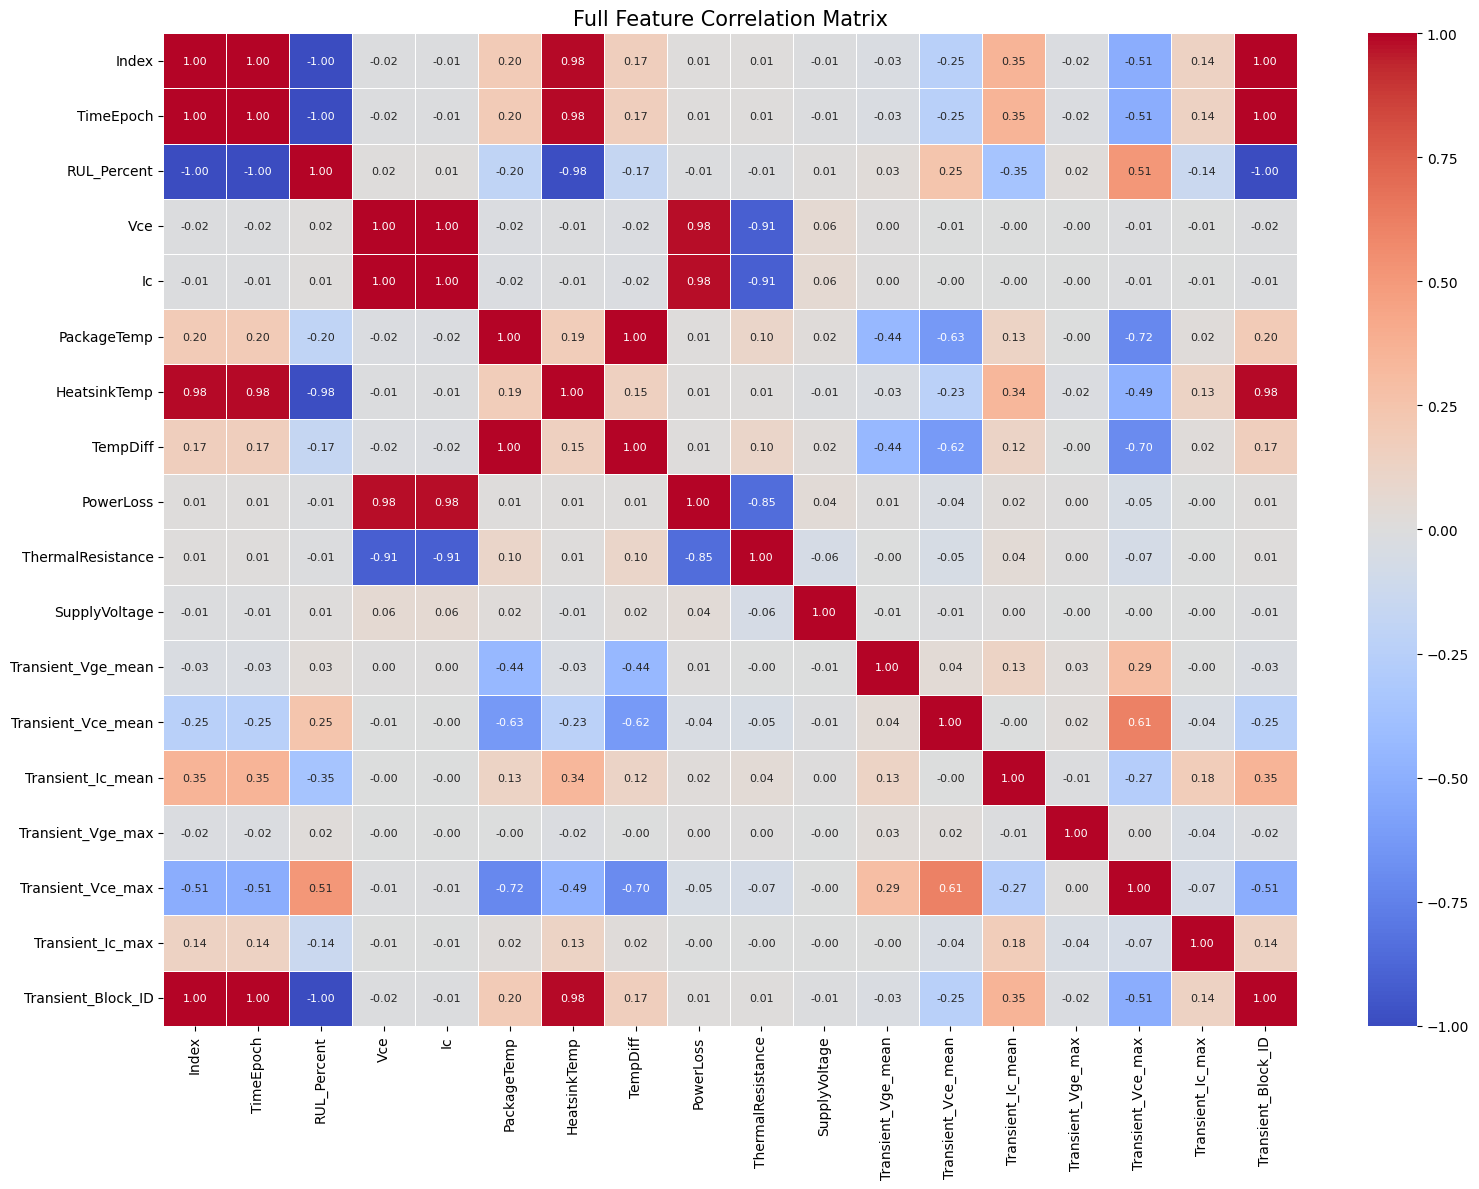

Dataset    : 41,752 rows × 12 features
Train size : 33,436 rows
Test size  : 8,316 rows
RUL range  : 0.0 → 100.0

Features used:
  Vce
  Ic
  PackageTemp
  PowerLoss
  ThermalResistance
  SupplyVoltage
  Transient_Vge_mean
  Transient_Vce_mean
  Transient_Ic_mean
  Transient_Vge_max
  Transient_Vce_max
  Transient_Ic_max


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score


# ── Load ───────────────────────────────────────────────────────────────────────
df = pd.read_csv("/kaggle/input/datasets/dharinees/igbt-rul/IGBT_RUL_ALL.csv")   # update path if needed
df.columns = df.columns.str.strip()
import matplotlib.pyplot as plt
import seaborn as sns


corr_df = df.corr()

plt.figure(figsize=(16, 12)) 
sns.heatmap(corr_df, 
            annot=True, 
            cmap='coolwarm', 
            fmt='.2f',
            linewidths=0.5, 
            annot_kws={'size': 8})

plt.title('Full Feature Correlation Matrix', fontsize=15)
plt.tight_layout()
plt.show()

FEATURES = [
    'Vce', 'Ic', 'PackageTemp', 'PowerLoss', 'ThermalResistance', 'SupplyVoltage',
    'Transient_Vge_mean', 'Transient_Vce_mean', 'Transient_Ic_mean',
    'Transient_Vge_max',  'Transient_Vce_max',  'Transient_Ic_max'
]

X      = df[FEATURES]
y      = df['RUL_Percent']
groups = df['Transient_Block_ID']


gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx].reset_index(drop=True), X.iloc[test_idx].reset_index(drop=True)
y_train, y_test = y.iloc[train_idx].reset_index(drop=True), y.iloc[test_idx].reset_index(drop=True)


scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit only on train!
X_test_sc  = scaler.transform(X_test)

print(f'Dataset    : {len(df):,} rows × {len(FEATURES)} features')
print(f'Train size : {len(X_train):,} rows')
print(f'Test size  : {len(X_test):,} rows')
print(f'RUL range  : {y.min():.1f} → {y.max():.1f}')
print(f'\nFeatures used:')
for f in FEATURES:
    print(f'  {f}')

---
## Results Tracker
Run this once after setup. Each model block below appends its scores here.

In [6]:
results = []

---
## 1. Linear Regression
Baseline model. Fits a hyperplane through the feature space using Ordinary Least Squares. **Requires scaling** — features span very different ranges (e.g., PackageTemp ~300 vs Transient_Ic_max ~0.05). Without scaling, OLS coefficients are dominated by large-magnitude features.

Expected: Low R² — RUL has a nonlinear relationship with physical precursors once time proxies are removed.

In [21]:
from sklearn.linear_model import LinearRegression

# Uses scaled features
lr_model = LinearRegression()
lr_model.fit(X_train_sc, y_train)

y_train_pred = lr_model.predict(X_train_sc)
y_test_pred  = lr_model.predict(X_test_sc)

train_r2 = r2_score(y_train, y_train_pred)
test_r2  = r2_score(y_test,  y_test_pred)
rmse     = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae      = np.mean(np.abs(y_test - y_test_pred))

print('=' * 55)
print('  1. Linear Regression')
print(f'  Train R²  : {train_r2:.6f}')
print(f'  Test  R²  : {test_r2:.6f}')
print(f'  RMSE      : {rmse:.4f}')
print(f'  MAE       : {mae:.4f}')

results.append({'Model': '1. Linear Regression',
                'Train R²': round(train_r2, 4), 'Test R²': round(test_r2, 4),
                'RMSE': round(rmse, 4), 'MAE': round(mae, 4)})

  1. Linear Regression
  Train R²  : 0.522240
  Test  R²  : -2.097824
  RMSE      : 57.7278
  MAE       : 23.5200


---
## 2. Multiple Linear Regression (with Interaction Terms)
Extends Linear Regression by adding engineered interaction terms between physically meaningful feature pairs: Vce×Ic (instantaneous power proxy), PackageTemp×PowerLoss (thermal stress), and Vce×Transient_Vce_max (steady-state vs transient voltage ratio). These capture joint degradation effects that individual features miss. **Requires scaling.**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np


mlr_model = LinearRegression()
mlr_model.fit(X_train_sc, y_train)

y_train_pred = mlr_model.predict(X_train_sc)
y_test_pred  = mlr_model.predict(X_test_sc)

train_r2 = r2_score(y_train, y_train_pred)
test_r2  = r2_score(y_test, y_test_pred)
rmse     = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae      = np.mean(np.abs(y_test - y_test_pred))

results.append({
    'Model': 'Multiple Linear Regression',
    'Best Configuration': 'Default',
    'Train R²': train_r2,
    'Test R²': test_r2,
    'MAE': mae,
    'RMSE': rmse
})

print('='*55)
print('  2. Multiple Linear Regression (Baseline)')
print(f'  Train R²  : {train_r2:.6f}')
print(f'  Test  R²  : {test_r2:.6f}')
print(f'  RMSE      : {rmse:.4f}')
print(f'  MAE       : {mae:.4f}')

  2. Multiple Linear Regression (Baseline)
  Train R²  : 0.522240
  Test  R²  : -2.097824
  RMSE      : 57.7278
  MAE       : 23.5200


---
## 3. Polynomial Regression
Adds polynomial and cross-product feature transformations to capture nonlinear degradation curves. Degree is selected by comparing test R² for degrees 1–3. **Requires scaling** (applied inside pipeline after polynomial expansion). Note: degree 3 with 12 features creates a very large feature space — fit on a subsample for speed.

In [23]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

best_r2_poly     = -np.inf  # ← cleaner than -999
best_result_poly = None

print("="*60)
print("ALL POLYNOMIAL REGRESSION RESULTS")
print("="*60)

for d in [1, 2, 3]:
    poly = PolynomialFeatures(degree=d, include_bias=False)

    X_train_poly = poly.fit_transform(X_train_sc)
    X_test_poly  = poly.transform(X_test_sc)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_train_pred = model.predict(X_train_poly)
    y_test_pred  = model.predict(X_test_poly)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2  = r2_score(y_test,  y_test_pred)
    rmse     = np.sqrt(mean_squared_error(y_test, y_test_pred))
    mae      = mean_absolute_error(y_test, y_test_pred)  # ← use sklearn instead of manual np.mean

    print(f"  Degree {d} → Train R²: {train_r2:.4f}  Test R²: {test_r2:.4f}  RMSE: {rmse:.4f}  MAE: {mae:.4f}")

    if test_r2 > best_r2_poly:
        best_r2_poly     = test_r2
        best_result_poly = {
            'Model':    f'Polynomial Regression (Best Degree = {d})',
            'Train R²': round(train_r2, 4),
            'Test R²':  round(test_r2,  4),
            'RMSE':     round(rmse, 4),
            'MAE':      round(mae,  4),
        }

print("\n" + "="*60)
print("BEST POLYNOMIAL REGRESSION MODEL")
print("="*60)
print("Model: ", best_result_poly['Model'])
print("Train R²:", best_result_poly['Train R²'])
print("Test  R²:", best_result_poly['Test R²'])
print("RMSE:    ", best_result_poly['RMSE'])
print("MAE:     ", best_result_poly['MAE'])

results.append(best_result_poly)

ALL POLYNOMIAL REGRESSION RESULTS
  Degree 1 → Train R²: 0.5222  Test R²: -2.0978  RMSE: 57.7278  MAE: 23.5200
  Degree 2 → Train R²: 0.9757  Test R²: -2.6243  RMSE: 62.4408  MAE: 10.6925
  Degree 3 → Train R²: 0.9908  Test R²: -277.4625  RMSE: 547.3188  MAE: 126.4454

BEST POLYNOMIAL REGRESSION MODEL
Model:  Polynomial Regression (Best Degree = 1)
Train R²: 0.5222
Test  R²: -2.0978
RMSE:     57.7278
MAE:      23.52


---
## 4. Lasso Regression
L1 regularization — drives irrelevant feature coefficients to exactly zero, performing automatic feature selection. Useful here because several features (SupplyVoltage, ThermalResistance) have near-zero correlation with RUL. Alpha controls sparsity. **Requires scaling** — L1 penalty is not scale-invariant.

In [24]:
from sklearn.linear_model import Lasso

best_a_lasso, best_r2_lasso = None, -999
print('  Lasso alpha search (scaled features):')
for a in [0.0001, 0.001, 0.01, 0.1, 1, 10]:
    m = Lasso(alpha=a, max_iter=50000)
    m.fit(X_train_sc, y_train)
    r2     = r2_score(y_test, m.predict(X_test_sc))
    n_zero = np.sum(m.coef_ == 0)
    print(f'  alpha={a:<7}  Test R²: {r2:.4f}  zeroed features: {n_zero}/{len(FEATURES)}')
    if r2 > best_r2_lasso:
        best_r2_lasso = r2; best_a_lasso = a

print(f'\nBest alpha: {best_a_lasso}')

lasso_model = Lasso(alpha=best_a_lasso, max_iter=50000)
lasso_model.fit(X_train_sc, y_train)

y_train_pred = lasso_model.predict(X_train_sc)
y_test_pred  = lasso_model.predict(X_test_sc)

train_r2 = r2_score(y_train, y_train_pred)
test_r2  = r2_score(y_test,  y_test_pred)
rmse     = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae      = np.mean(np.abs(y_test - y_test_pred))

print('=' * 55)
print('  4. Lasso Regression')
print(f'  Train R²  : {train_r2:.6f}')
print(f'  Test  R²  : {test_r2:.6f}')
print(f'  RMSE      : {rmse:.4f}')
print(f'  MAE       : {mae:.4f}')

results.append({'Model': '4. Lasso Regression',
                'Train R²': round(train_r2, 4), 'Test R²': round(test_r2, 4),
                'RMSE': round(rmse, 4), 'MAE': round(mae, 4)})

# Show which features survived
lasso_coefs = pd.Series(lasso_model.coef_, index=FEATURES)
print('\nLasso feature coefficients (0 = eliminated):')
print(lasso_coefs.to_string())

  Lasso alpha search (scaled features):


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.169e+05, tolerance: 2.585e+03
  model = cd_fast.enet_coordinate_descent(


  alpha=0.0001   Test R²: -2.0985  zeroed features: 0/12
  alpha=0.001    Test R²: -2.1041  zeroed features: 0/12
  alpha=0.01     Test R²: -2.1073  zeroed features: 1/12
  alpha=0.1      Test R²: -1.9256  zeroed features: 1/12
  alpha=1        Test R²: -0.4950  zeroed features: 7/12
  alpha=10       Test R²: 0.0913  zeroed features: 11/12

Best alpha: 10
  4. Lasso Regression
  Train R²  : 0.101837
  Test  R²  : 0.091345
  RMSE      : 31.2649
  MAE       : 28.5654

Lasso feature coefficients (0 = eliminated):
Vce                   0.000000
Ic                    0.000000
PackageTemp          -0.000000
PowerLoss            -0.000000
ThermalResistance    -0.000000
SupplyVoltage         0.000000
Transient_Vge_mean   -0.000000
Transient_Vce_mean    0.000000
Transient_Ic_mean    -0.000000
Transient_Vge_max     0.000000
Transient_Vce_max     3.368869
Transient_Ic_max     -0.000000


---
## 5. Ridge Regression
L2 regularization — shrinks all coefficients but keeps them non-zero. Better than Lasso when all features contribute somewhat. Handles multicollinearity between correlated features (e.g., Transient_Vce_mean and Transient_Vce_max are both Vce-derived). **Requires scaling** — L2 penalty is not scale-invariant.

In [25]:
from sklearn.linear_model import Ridge

best_a_ridge, best_r2_ridge = None, -999
print('  Ridge alpha search (scaled features):')
for a in [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]:
    m = Ridge(alpha=a)
    m.fit(X_train_sc, y_train)
    r2 = r2_score(y_test, m.predict(X_test_sc))
    print(f'  alpha={a:<7}  Test R²: {r2:.4f}')
    if r2 > best_r2_ridge:
        best_r2_ridge = r2; best_a_ridge = a

print(f'\nBest alpha: {best_a_ridge}')

ridge_model = Ridge(alpha=best_a_ridge)
ridge_model.fit(X_train_sc, y_train)

y_train_pred = ridge_model.predict(X_train_sc)
y_test_pred  = ridge_model.predict(X_test_sc)

train_r2 = r2_score(y_train, y_train_pred)
test_r2  = r2_score(y_test,  y_test_pred)
rmse     = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae      = np.mean(np.abs(y_test - y_test_pred))

print('=' * 55)
print('  5. Ridge Regression')
print(f'  Train R²  : {train_r2:.6f}')
print(f'  Test  R²  : {test_r2:.6f}')
print(f'  RMSE      : {rmse:.4f}')
print(f'  MAE       : {mae:.4f}')

results.append({'Model': '5. Ridge Regression',
                'Train R²': round(train_r2, 4), 'Test R²': round(test_r2, 4),
                'RMSE': round(rmse, 4), 'MAE': round(mae, 4)})

  Ridge alpha search (scaled features):
  alpha=0.0001   Test R²: -2.0978
  alpha=0.001    Test R²: -2.0978
  alpha=0.01     Test R²: -2.0980
  alpha=0.1      Test R²: -2.0994
  alpha=1        Test R²: -2.1084
  alpha=10       Test R²: -2.1070
  alpha=100      Test R²: -1.9222

Best alpha: 100
  5. Ridge Regression
  Train R²  : 0.520500
  Test  R²  : -1.922168
  RMSE      : 56.0673
  MAE       : 23.4549


---
## 6. Elastic Net
Combines L1 + L2 regularization. The `l1_ratio` parameter balances between Lasso-style sparsity and Ridge-style shrinkage. Particularly suited when features are correlated AND some may be irrelevant — both conditions exist in this dataset. **Requires scaling.**

In [26]:
from sklearn.linear_model import ElasticNet

best_params_en, best_r2_en = None, -999
print('  Elastic Net search (scaled features):')
for a in [0.0001, 0.001, 0.01, 0.1]:
    for l in [0.2, 0.5, 0.8]:
        m = ElasticNet(alpha=a, l1_ratio=l, max_iter=50000)
        m.fit(X_train_sc, y_train)
        r2 = r2_score(y_test, m.predict(X_test_sc))
        print(f'  alpha={a}  l1_ratio={l}  Test R²: {r2:.4f}')
        if r2 > best_r2_en:
            best_r2_en = r2; best_params_en = (a, l)

a_en, l_en = best_params_en
print(f'\nBest: alpha={a_en}  l1_ratio={l_en}')

en_model = ElasticNet(alpha=a_en, l1_ratio=l_en, max_iter=50000)
en_model.fit(X_train_sc, y_train)

y_train_pred = en_model.predict(X_train_sc)
y_test_pred  = en_model.predict(X_test_sc)

train_r2 = r2_score(y_train, y_train_pred)
test_r2  = r2_score(y_test,  y_test_pred)
rmse     = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae      = np.mean(np.abs(y_test - y_test_pred))

print('=' * 55)
print('  6. Elastic Net')
print(f'  Train R²  : {train_r2:.6f}')
print(f'  Test  R²  : {test_r2:.6f}')
print(f'  RMSE      : {rmse:.4f}')
print(f'  MAE       : {mae:.4f}')

results.append({'Model': '6. Elastic Net',
                'Train R²': round(train_r2, 4), 'Test R²': round(test_r2, 4),
                'RMSE': round(rmse, 4), 'MAE': round(mae, 4)})

  Elastic Net search (scaled features):
  alpha=0.0001  l1_ratio=0.2  Test R²: -2.1137
  alpha=0.0001  l1_ratio=0.5  Test R²: -2.1116


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.308e+03, tolerance: 2.585e+03
  model = cd_fast.enet_coordinate_descent(


  alpha=0.0001  l1_ratio=0.8  Test R²: -2.1063
  alpha=0.001  l1_ratio=0.2  Test R²: -2.0731
  alpha=0.001  l1_ratio=0.5  Test R²: -2.0929
  alpha=0.001  l1_ratio=0.8  Test R²: -2.1114
  alpha=0.01  l1_ratio=0.2  Test R²: -1.6146
  alpha=0.01  l1_ratio=0.5  Test R²: -1.7839
  alpha=0.01  l1_ratio=0.8  Test R²: -1.9733
  alpha=0.1  l1_ratio=0.2  Test R²: -0.0631
  alpha=0.1  l1_ratio=0.5  Test R²: -0.3495
  alpha=0.1  l1_ratio=0.8  Test R²: -0.9819

Best: alpha=0.1  l1_ratio=0.2
  6. Elastic Net
  Train R²  : 0.438724
  Test  R²  : -0.063132
  RMSE      : 33.8182
  MAE       : 23.4654


---
## 7. Support Vector Regressor (SVR)
Kernel-based method that finds a regression surface maximizing margin. The RBF kernel maps features to a higher-dimensional space, capturing nonlinear degradation relationships.

**Scaling is critical for SVR** — the RBF kernel computes Euclidean distances between feature vectors. If PackageTemp (~300) and Transient_Ic_max (~0.05) are unscaled, the distance metric is dominated by PackageTemp and the kernel becomes meaningless. StandardScaler ensures all features contribute equally to the distance computation.

Hyperparameters tuned: C (margin penalty) and gamma (kernel bandwidth).

In [7]:
import cupy as cp
from cuml.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Move to GPU
X_train_gpu = cp.asarray(X_train_sc.astype(np.float32))
X_test_gpu  = cp.asarray(X_test_sc.astype(np.float32))
y_train_gpu = cp.asarray(y_train.astype(np.float32))

best_r2      = -np.inf
best_result  = None
best_pred_te = None  # ← fix: track best test predictions

print("="*60)
print("ALL SVR RESULTS — GPU T4")
print("="*60)

for C in [10, 100]:
    for eps in [0.01, 0.1]:
        for g in [0.001, 0.01, 0.1, 1]:
            model = SVR(kernel='rbf', C=C, epsilon=eps, gamma=g)
            model.fit(X_train_gpu, y_train_gpu)

            pred_tr = cp.asnumpy(model.predict(X_train_gpu))
            pred_te = cp.asnumpy(model.predict(X_test_gpu))

            result = {
                "params":      {"C": C, "epsilon": eps, "gamma": g},
                "r2_train":    round(r2_score(y_train, pred_tr), 4),
                "rmse_train":  round(np.sqrt(mean_squared_error(y_train, pred_tr)), 4),
                "r2_test":     round(r2_score(y_test, pred_te), 4),
                "rmse_test":   round(np.sqrt(mean_squared_error(y_test, pred_te)), 4),
                "mae_test":    round(mean_absolute_error(y_test, pred_te), 4),  # ← compute per iteration
            }

            print(f"\n--- C={C} eps={eps} gamma={g} ---")
            print(f"  TRAIN R2={result['r2_train']}  RMSE={result['rmse_train']}")
            print(f"  TEST  R2={result['r2_test']}  RMSE={result['rmse_test']}  MAE={result['mae_test']}")

            if result["r2_test"] > best_r2:
                best_r2      = result["r2_test"]
                best_result  = result
                best_pred_te = pred_te  # ← fix: save predictions of the best model

# BEST MODEL
print("\n" + "="*60)
print("BEST SVR MODEL")
print("="*60)
print("Best Params:", best_result["params"])
print("Train R2:  ", best_result["r2_train"])
print("Test  R2:  ", best_result["r2_test"])
print("RMSE:      ", best_result["rmse_test"])
print("MAE:       ", best_result["mae_test"])

results.append({
    'Model':    'SVR (Best - GPU)',
    'Train R²': best_result["r2_train"],
    'Test R²':  best_result["r2_test"],
    'RMSE':     best_result["rmse_test"],
    'MAE':      best_result["mae_test"],  # ← fix: now correctly from the best model
})

ALL SVR RESULTS — GPU T4

--- C=10 eps=0.01 gamma=0.001 ---
  TRAIN R2=0.5747  RMSE=18.1332
  TEST  R2=-0.0576  RMSE=33.7304  MAE=20.8891

--- C=10 eps=0.01 gamma=0.01 ---
  TRAIN R2=0.7719  RMSE=13.2805
  TEST  R2=0.6692  RMSE=18.8639  MAE=14.6249

--- C=10 eps=0.01 gamma=0.1 ---
  TRAIN R2=0.9129  RMSE=8.2035
  TEST  R2=0.8692  RMSE=11.8609  MAE=8.7542

--- C=10 eps=0.01 gamma=1 ---
  TRAIN R2=0.9668  RMSE=5.067
  TEST  R2=0.7272  RMSE=17.1315  MAE=10.8497

--- C=10 eps=0.1 gamma=0.001 ---
  TRAIN R2=0.5746  RMSE=18.1343
  TEST  R2=-0.0572  RMSE=33.7239  MAE=20.8869

--- C=10 eps=0.1 gamma=0.01 ---
  TRAIN R2=0.7719  RMSE=13.2797
  TEST  R2=0.6692  RMSE=18.8656  MAE=14.6234

--- C=10 eps=0.1 gamma=0.1 ---
  TRAIN R2=0.913  RMSE=8.2032
  TEST  R2=0.8689  RMSE=11.8777  MAE=8.7595

--- C=10 eps=0.1 gamma=1 ---
  TRAIN R2=0.9668  RMSE=5.0629
  TEST  R2=0.7276  RMSE=17.1175  MAE=10.8513

--- C=100 eps=0.01 gamma=0.001 ---
  TRAIN R2=0.6519  RMSE=16.4036
  TEST  R2=0.1784  RMSE=29.7292  MA

---
## 8. K-Nearest Neighbors (KNN)
Predicts RUL as a weighted average of the k most similar training samples in feature space.

**Scaling is critical for KNN** — same reason as SVR. KNN uses Euclidean distance to find neighbors. Without scaling, PackageTemp would completely dominate neighbor selection, making all other features irrelevant. StandardScaler ensures meaningful distance comparisons across all 12 features.

In [19]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error

best_r2      = -np.inf
best_result  = None
best_pred_te = None

print("="*60)
print("ALL KNN RESULTS — CPU")
print("="*60)

for k in [3, 5, 7, 9, 15]:
    for w in ['uniform', 'distance']:
        model = KNeighborsRegressor(n_neighbors=k, weights=w)
        model.fit(X_train_sc, y_train)        # ← was X_train_s
        pred_tr = model.predict(X_train_sc)   # ← was X_train_s
        pred_te = model.predict(X_test_sc)    # ← was X_test_s

        result = {
            "params":     {"k": k, "weights": w},
            "r2_train":   round(r2_score(y_train, pred_tr), 4),
            "rmse_train": round(np.sqrt(mean_squared_error(y_train, pred_tr)), 4),
            "r2_test":    round(r2_score(y_test, pred_te), 4),
            "rmse_test":  round(np.sqrt(mean_squared_error(y_test, pred_te)), 4),
            "mae_test":   round(mean_absolute_error(y_test, pred_te), 4),
        }

        print(f"\n--- k={k} weights={w} ---")
        print(f"  TRAIN R2={result['r2_train']}  RMSE={result['rmse_train']}")
        print(f"  TEST  R2={result['r2_test']}  RMSE={result['rmse_test']}  MAE={result['mae_test']}")

        if result["r2_test"] > best_r2:
            best_r2      = result["r2_test"]
            best_result  = result
            best_pred_te = pred_te

# BEST MODEL
print("\n" + "="*60)
print("BEST KNN MODEL")
print("="*60)
print("Best Params:", best_result["params"])
print("Train R2:  ", best_result["r2_train"])
print("Test  R2:  ", best_result["r2_test"])
print("RMSE:      ", best_result["rmse_test"])
print("MAE:       ", best_result["mae_test"])

results.append({
    'Model':    'KNN (Best)',
    'Train R²': best_result["r2_train"],
    'Test R²':  best_result["r2_test"],
    'RMSE':     best_result["rmse_test"],
    'MAE':      best_result["mae_test"],
})

ALL KNN RESULTS — CPU

--- k=3 weights=uniform ---
  TRAIN R2=0.9911  RMSE=2.6277
  TEST  R2=0.7082  RMSE=17.7185  MAE=12.8135

--- k=3 weights=distance ---
  TRAIN R2=1.0  RMSE=0.0
  TEST  R2=0.7087  RMSE=17.7018  MAE=12.7873

--- k=5 weights=uniform ---
  TRAIN R2=0.9814  RMSE=3.7965
  TEST  R2=0.7093  RMSE=17.6853  MAE=12.7655

--- k=5 weights=distance ---
  TRAIN R2=1.0  RMSE=0.0
  TEST  R2=0.7103  RMSE=17.6536  MAE=12.7262

--- k=7 weights=uniform ---
  TRAIN R2=0.9733  RMSE=4.5475
  TEST  R2=0.7092  RMSE=17.6859  MAE=12.8008

--- k=7 weights=distance ---
  TRAIN R2=1.0  RMSE=0.0
  TEST  R2=0.7108  RMSE=17.6369  MAE=12.7414

--- k=9 weights=uniform ---
  TRAIN R2=0.9673  RMSE=5.0314
  TEST  R2=0.7091  RMSE=17.6892  MAE=12.8334

--- k=9 weights=distance ---
  TRAIN R2=1.0  RMSE=0.0
  TEST  R2=0.7112  RMSE=17.6251  MAE=12.7639

--- k=15 weights=uniform ---
  TRAIN R2=0.9533  RMSE=6.0058
  TEST  R2=0.7066  RMSE=17.7646  MAE=12.9272

--- k=15 weights=distance ---
  TRAIN R2=1.0  RMSE=

---
## 9. Decision Tree Regressor
Partitions feature space into rectangular regions via recursive binary splits, predicting mean RUL per region. **Does NOT require scaling** — splits are based on feature thresholds, not distances. Magnitude of features doesn't affect split decisions.

Prone to overfitting if unconstrained — max_depth, min_samples_split and min_samples_leaf are tuned.

In [20]:
from sklearn.tree import DecisionTreeRegressor

best_params_dt, best_r2_dt = None, -999
for d in [5, 10, 15, 20, None]:
    for s in [2, 5, 10]:
        for l in [1, 2, 4]:
            m = DecisionTreeRegressor(max_depth=d, min_samples_split=s,
                                      min_samples_leaf=l, random_state=42)
            m.fit(X_train, y_train)       # raw unscaled features
            r2 = r2_score(y_test, m.predict(X_test))
            if r2 > best_r2_dt:
                best_r2_dt = r2; best_params_dt = (d, s, l)

d_dt, s_dt, l_dt = best_params_dt
print(f'Best: max_depth={d_dt}  min_split={s_dt}  min_leaf={l_dt}')

dt_model = DecisionTreeRegressor(max_depth=d_dt, min_samples_split=s_dt,
                                  min_samples_leaf=l_dt, random_state=42)
dt_model.fit(X_train, y_train)

y_train_pred = dt_model.predict(X_train)
y_test_pred  = dt_model.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2  = r2_score(y_test,  y_test_pred)
rmse     = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae      = np.mean(np.abs(y_test - y_test_pred))

print('=' * 55)
print('  9. Decision Tree')
print(f'  Train R²  : {train_r2:.6f}')
print(f'  Test  R²  : {test_r2:.6f}')
print(f'  RMSE      : {rmse:.4f}')
print(f'  MAE       : {mae:.4f}')

results.append({'Model': '9. Decision Tree',
                'Train R²': round(train_r2, 4), 'Test R²': round(test_r2, 4),
                'RMSE': round(rmse, 4), 'MAE': round(mae, 4)})

Best: max_depth=20  min_split=5  min_leaf=1
  9. Decision Tree
  Train R²  : 0.999998
  Test  R²  : 0.895119
  RMSE      : 10.6220
  MAE       : 6.7617


---
## 10. Random Forest Regressor
Ensemble of decision trees, each trained on a random bootstrap sample with a random feature subset at each split (bagging). Reduces the high variance of individual trees. **Does NOT require scaling** — inherits the threshold-based split logic of Decision Trees.

Feature importances reveal which physical signals most drive RUL predictions.

  Random Forest hyperparameter tuning (unscaled — tree-based):
  n=100  depth=10    max_features=sqrt   Test R²: 0.8485
  n=100  depth=10    max_features=0.5    Test R²: 0.9112
  n=100  depth=10    max_features=0.8    Test R²: 0.9313
  n=100  depth=10    max_features=1.0    Test R²: 0.9255
  n=100  depth=20    max_features=sqrt   Test R²: 0.8756
  n=100  depth=20    max_features=0.5    Test R²: 0.9155
  n=100  depth=20    max_features=0.8    Test R²: 0.9318
  n=100  depth=20    max_features=1.0    Test R²: 0.9243
  n=100  depth=None  max_features=sqrt   Test R²: 0.8793
  n=100  depth=None  max_features=0.5    Test R²: 0.9155
  n=100  depth=None  max_features=0.8    Test R²: 0.9325
  n=100  depth=None  max_features=1.0    Test R²: 0.9281
  n=200  depth=10    max_features=sqrt   Test R²: 0.8464
  n=200  depth=10    max_features=0.5    Test R²: 0.9090
  n=200  depth=10    max_features=0.8    Test R²: 0.9340
  n=200  depth=10    max_features=1.0    Test R²: 0.9248
  n=200  depth=20    max_

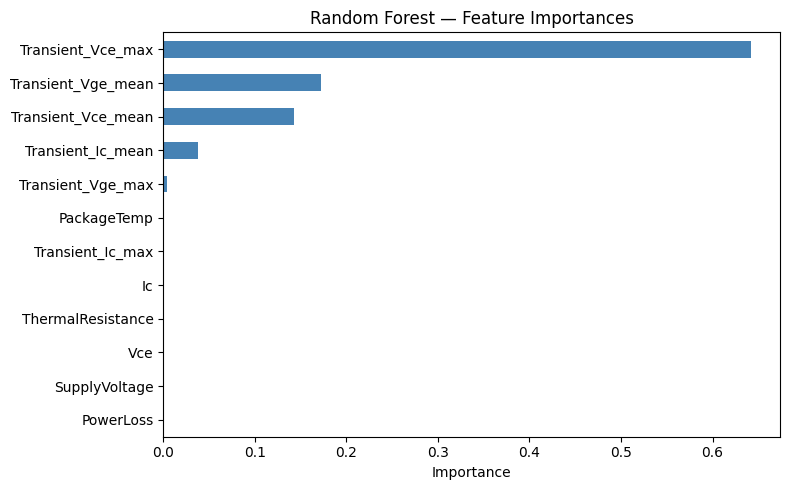


Top features:
Transient_Vce_max     0.641601
Transient_Vge_mean    0.171891
Transient_Vce_mean    0.142265
Transient_Ic_mean     0.038032
Transient_Vge_max     0.004278


In [ ]:
from sklearn.ensemble import RandomForestRegressor



best_params_rf, best_r2_rf = None, -999
print('  Random Forest hyperparameter tuning (unscaled — tree-based):')
for n in [100, 200]:
    for d in [10, 20, None]:
        for mf in ['sqrt', 0.5, 0.8, 1.0]:from sklearn.ensemble import RandomForestRegressor


best_params_rf, best_r2_rf = None, -999
print('  Random Forest hyperparameter tuning (unscaled — tree-based):')
for n in [100, 200]:
    for d in [10, 20, None]:
        for mf in ['sqrt', 0.5, 0.8, 1.0]:
            m = RandomForestRegressor(n_estimators=n, max_depth=d,
                                      max_features=mf, random_state=42, n_jobs=-1)
            m.fit(X_train, y_train)
            r2 = r2_score(y_test, m.predict(X_test))
            print(f'  n={n:<4} depth={str(d):<5} max_features={str(mf):<6} Test R²: {r2:.4f}')
            if r2 > best_r2_rf:
                best_r2_rf = r2; best_params_rf = (n, d, mf)

n_rf, d_rf, mf_rf = best_params_rf
print(f'\nBest: n_estimators={n_rf}  max_depth={d_rf}  max_features={mf_rf}')

rf_model = RandomForestRegressor(n_estimators=n_rf, max_depth=d_rf,
                                  max_features=mf_rf, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_train_pred = rf_model.predict(X_train)
y_test_pred  = rf_model.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2  = r2_score(y_test,  y_test_pred)
rmse     = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae      = np.mean(np.abs(y_test - y_test_pred))

print('=' * 55)
print('  10. Random Forest')
print(f'  Train R²  : {train_r2:.6f}')
print(f'  Test  R²  : {test_r2:.6f}')
print(f'  RMSE      : {rmse:.4f}')
print(f'  MAE       : {mae:.4f}')

results.append({'Model': '10. Random Forest',
                'Train R²': round(train_r2, 4), 'Test R²': round(test_r2, 4),
                'RMSE': round(rmse, 4), 'MAE': round(mae, 4)})

# Feature importance plot
imp = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
imp.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Random Forest — Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()
print('\nTop features:')
print(imp.sort_values(ascending=False).head(5).to_string())
            m = RandomForestRegressor(n_estimators=n, max_depth=d,
                                      max_features=mf, random_state=42, n_jobs=-1)
            m.fit(X_train, y_train)
            r2 = r2_score(y_test, m.predict(X_test))
            print(f'  n={n:<4} depth={str(d):<5} max_features={str(mf):<6} Test R²: {r2:.4f}')
            if r2 > best_r2_rf:
                best_r2_rf = r2; best_params_rf = (n, d, mf)

n_rf, d_rf, mf_rf = best_params_rf
print(f'\nBest: n_estimators={n_rf}  max_depth={d_rf}  max_features={mf_rf}')

rf_model = RandomForestRegressor(n_estimators=n_rf, max_depth=d_rf,
                                  max_features=mf_rf, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_train_pred = rf_model.predict(X_train)
y_test_pred  = rf_model.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2  = r2_score(y_test,  y_test_pred)
rmse     = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae      = np.mean(np.abs(y_test - y_test_pred))

print('=' * 55)
print('  10. Random Forest')
print(f'  Train R²  : {train_r2:.6f}')
print(f'  Test  R²  : {test_r2:.6f}')
print(f'  RMSE      : {rmse:.4f}')
print(f'  MAE       : {mae:.4f}')

results.append({'Model': '10. Random Forest',
                'Train R²': round(train_r2, 4), 'Test R²': round(test_r2, 4),
                'RMSE': round(rmse, 4), 'MAE': round(mae, 4)})

# Feature importance plot
imp = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
imp.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Random Forest — Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()
print('\nTop features:')
print(imp.sort_values(ascending=False).head(5).to_string())

---
## 11. AdaBoost Regressor
Sequential boosting — trains weak learners (shallow trees) one at a time, each focusing on the samples most poorly predicted by the previous ensemble. Final prediction is a weighted vote. **Does NOT require scaling** — base learners are decision stumps (threshold-based). Learning rate and number of estimators are tuned.

In [16]:
from sklearn.ensemble import AdaBoostRegressor

best_params_ada, best_r2_ada = None, -999
print('  AdaBoost search (unscaled — tree-based):')
for n in [50, 100, 200]:
    for lr in [0.01, 0.1, 0.5, 1.0]:
        m = AdaBoostRegressor(n_estimators=n, learning_rate=lr, random_state=42)
        m.fit(X_train, y_train)      # unscaled
        r2 = r2_score(y_test, m.predict(X_test))
        print(f'  n={n:<5}  lr={lr:<5}  Test R²: {r2:.4f}')
        if r2 > best_r2_ada:
            best_r2_ada = r2; best_params_ada = (n, lr)

n_ada, lr_ada = best_params_ada
print(f'\nBest: n_estimators={n_ada}  learning_rate={lr_ada}')

ada_model = AdaBoostRegressor(n_estimators=n_ada, learning_rate=lr_ada, random_state=42)
ada_model.fit(X_train, y_train)

y_train_pred = ada_model.predict(X_train)
y_test_pred  = ada_model.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2  = r2_score(y_test,  y_test_pred)
rmse     = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae      = np.mean(np.abs(y_test - y_test_pred))

print('=' * 55)
print('  11. AdaBoost')
print(f'  Train R²  : {train_r2:.6f}')
print(f'  Test  R²  : {test_r2:.6f}')
print(f'  RMSE      : {rmse:.4f}')
print(f'  MAE       : {mae:.4f}')

results.append({'Model': '11. AdaBoost',
                'Train R²': round(train_r2, 4), 'Test R²': round(test_r2, 4),
                'RMSE': round(rmse, 4), 'MAE': round(mae, 4)})

  AdaBoost search (unscaled — tree-based):
  n=50     lr=0.01   Test R²: 0.7397
  n=50     lr=0.1    Test R²: 0.8672
  n=50     lr=0.5    Test R²: 0.9042
  n=50     lr=1.0    Test R²: 0.9030
  n=100    lr=0.01   Test R²: 0.7431
  n=100    lr=0.1    Test R²: 0.8874
  n=100    lr=0.5    Test R²: 0.9060
  n=100    lr=1.0    Test R²: 0.9021
  n=200    lr=0.01   Test R²: 0.8189
  n=200    lr=0.1    Test R²: 0.8994
  n=200    lr=0.5    Test R²: 0.9063
  n=200    lr=1.0    Test R²: 0.9034

Best: n_estimators=200  learning_rate=0.5
  11. AdaBoost
  Train R²  : 0.894063
  Test  R²  : 0.906255
  RMSE      : 10.0423
  MAE       : 8.6197


---
## 12. Gradient Boosting Regressor
Builds trees sequentially, each fitting the **negative gradient (residuals)** of the loss function from the previous ensemble — gradient descent in function space. Generally the strongest tree-based method. **Does NOT require scaling** — threshold-based splits.

Four hyperparameters tuned: n_estimators, learning_rate, max_depth, subsample (stochastic gradient boosting).

In [17]:
from sklearn.ensemble import GradientBoostingRegressor

best_params_gb, best_r2_gb = None, -999
print('  Gradient Boosting search (unscaled — tree-based):')
for n in [100, 200, 300]:
    for lr in [0.05, 0.1, 0.2]:
        for d in [3, 5, 7]:
            for s in [0.8, 1.0]:
                m = GradientBoostingRegressor(n_estimators=n, learning_rate=lr,
                                              max_depth=d, subsample=s, random_state=42)
                m.fit(X_train, y_train)     # unscaled
                r2 = r2_score(y_test, m.predict(X_test))
                if r2 > best_r2_gb:
                    best_r2_gb = r2; best_params_gb = (n, lr, d, s)
                    print(f'  NEW BEST → n={n}  lr={lr}  depth={d}  sub={s}  R²={r2:.4f}')

n_gb, lr_gb, d_gb, s_gb = best_params_gb
print(f'\nFinal best: n={n_gb}  lr={lr_gb}  depth={d_gb}  subsample={s_gb}')

gb_model = GradientBoostingRegressor(n_estimators=n_gb, learning_rate=lr_gb,
                                      max_depth=d_gb, subsample=s_gb, random_state=42)
gb_model.fit(X_train, y_train)

y_train_pred = gb_model.predict(X_train)
y_test_pred  = gb_model.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2  = r2_score(y_test,  y_test_pred)
rmse     = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae      = np.mean(np.abs(y_test - y_test_pred))

print('=' * 55)
print('  12. Gradient Boosting')
print(f'  Train R²  : {train_r2:.6f}')
print(f'  Test  R²  : {test_r2:.6f}')
print(f'  RMSE      : {rmse:.4f}')
print(f'  MAE       : {mae:.4f}')

results.append({'Model': '12. Gradient Boosting',
                'Train R²': round(train_r2, 4), 'Test R²': round(test_r2, 4),
                'RMSE': round(rmse, 4), 'MAE': round(mae, 4)})

  Gradient Boosting search (unscaled — tree-based):
  NEW BEST → n=100  lr=0.05  depth=3  sub=0.8  R²=0.9446
  NEW BEST → n=100  lr=0.05  depth=5  sub=0.8  R²=0.9498
  NEW BEST → n=100  lr=0.1  depth=3  sub=0.8  R²=0.9530
  NEW BEST → n=100  lr=0.1  depth=3  sub=1.0  R²=0.9537
  NEW BEST → n=100  lr=0.2  depth=5  sub=1.0  R²=0.9561

Final best: n=100  lr=0.2  depth=5  subsample=1.0
  12. Gradient Boosting
  Train R²  : 0.999817
  Test  R²  : 0.956084
  RMSE      : 6.8734
  MAE       : 5.0175


---
## Summary Table

In [27]:
results_df = (pd.DataFrame(results)
               .sort_values('Test R²', ascending=False)
               .reset_index(drop=True))
results_df.index += 1

# Add scaling note
scaling_map = {
    '1. Linear Regression'                            : 'Yes',
    '2. Multiple Linear Regression (Interactions)'    : 'Yes',
    '4. Lasso Regression'                             : 'Yes',
    '5. Ridge Regression'                             : 'Yes',
    '6. Elastic Net'                                  : 'Yes',
    '7. SVR (RBF Kernel)'                             : 'Yes ✓ (distance-based)',
    '8. K-Nearest Neighbors'                          : 'Yes ✓ (distance-based)',
    '9. Decision Tree'                                : 'No  (threshold-based)',
    '10. Random Forest'                               : 'No  (threshold-based)',
    '11. AdaBoost'                                    : 'No  (threshold-based)',
    '12. Gradient Boosting'                           : 'No  (threshold-based)',
}
results_df['Scaling Applied'] = results_df['Model'].map(
    lambda m: next((v for k,v in scaling_map.items() if k in m), 'Yes')
)

print(results_df.to_string())

                                      Model  Train R²  Test R²     RMSE      MAE        Scaling Applied
1                     12. Gradient Boosting    0.9998   0.9561   6.8734   5.0175  No  (threshold-based)
2                         10. Random Forest    1.0000   0.9340   8.4254   6.3263  No  (threshold-based)
3                              11. AdaBoost    0.8941   0.9063  10.0423   8.6197  No  (threshold-based)
4                          9. Decision Tree    1.0000   0.8951  10.6220   6.7617  No  (threshold-based)
5                          9. Decision Tree    1.0000   0.8951  10.6220   6.7617  No  (threshold-based)
6                          SVR (Best - GPU)    0.9129   0.8692  11.8609   8.7542                    Yes
7                                KNN (Best)    1.0000   0.7112  17.6251  12.7639                    Yes
8                       4. Lasso Regression    0.1018   0.0913  31.2649  28.5654                    Yes
9                            6. Elastic Net    0.4387  -0.0631  

---
## Model Comparison Charts

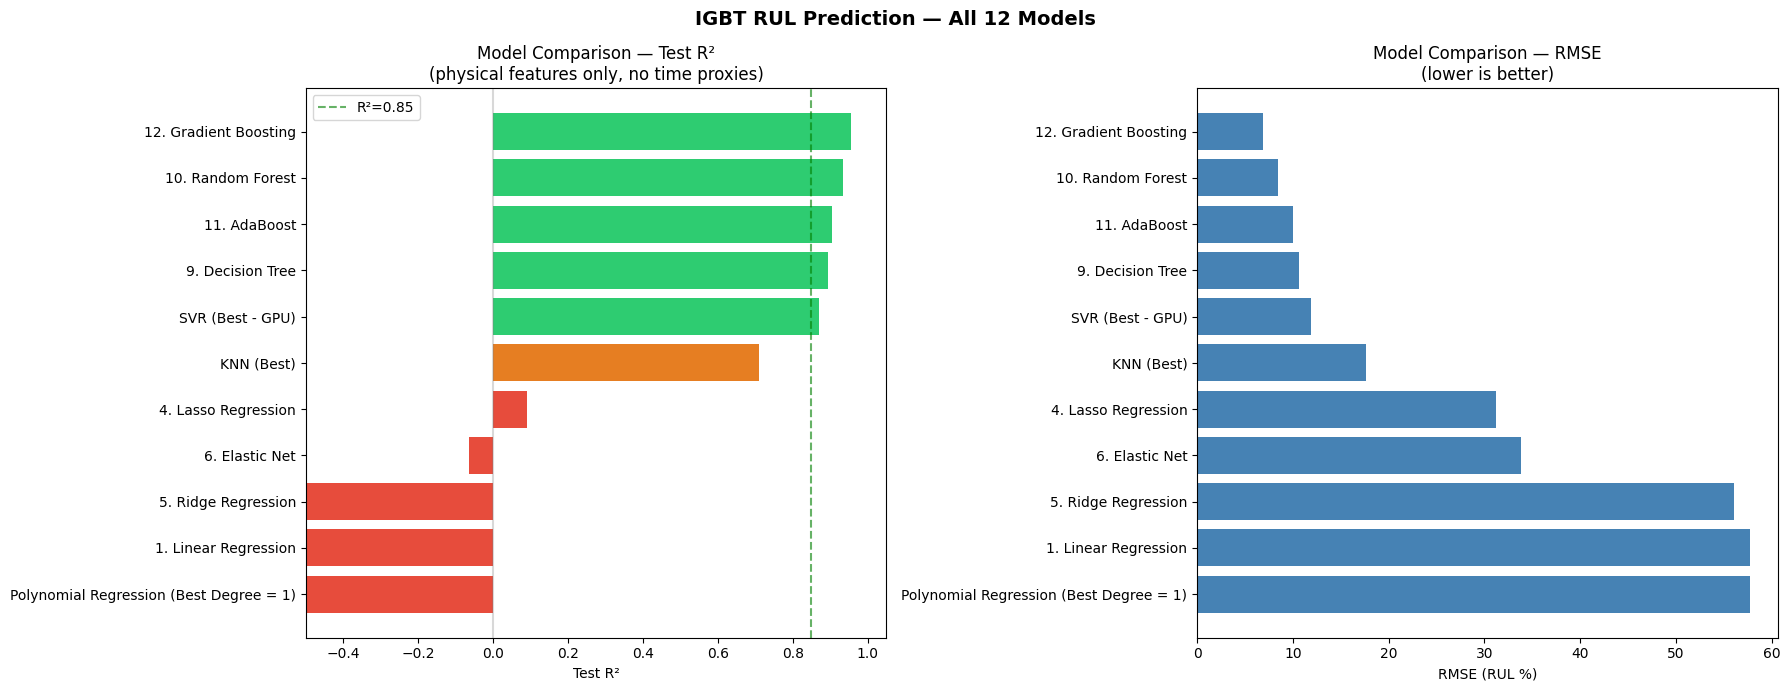

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

models_sorted = results_df['Model']
r2_vals   = results_df['Test R²']
rmse_vals = results_df['RMSE']

colors_r2 = ['#2ecc71' if r >= 0.85 else '#e67e22' if r >= 0.6 else '#e74c3c'
             for r in r2_vals]

axes[0].barh(models_sorted[::-1], r2_vals[::-1], color=colors_r2[::-1])
axes[0].axvline(0.85, color='green',  linestyle='--', alpha=0.6, label='R²=0.85')
axes[0].axvline(0.0,  color='gray',   linestyle='-',  alpha=0.3)
axes[0].set_xlabel('Test R²')
axes[0].set_title('Model Comparison — Test R²\n(physical features only, no time proxies)')
axes[0].legend()
axes[0].set_xlim(-0.5, 1.05)

axes[1].barh(models_sorted[::-1], rmse_vals[::-1], color='steelblue')
axes[1].set_xlabel('RMSE (RUL %)')
axes[1].set_title('Model Comparison — RMSE\n(lower is better)')

plt.suptitle('IGBT RUL Prediction — All 12 Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Feature Correlation Heatmap

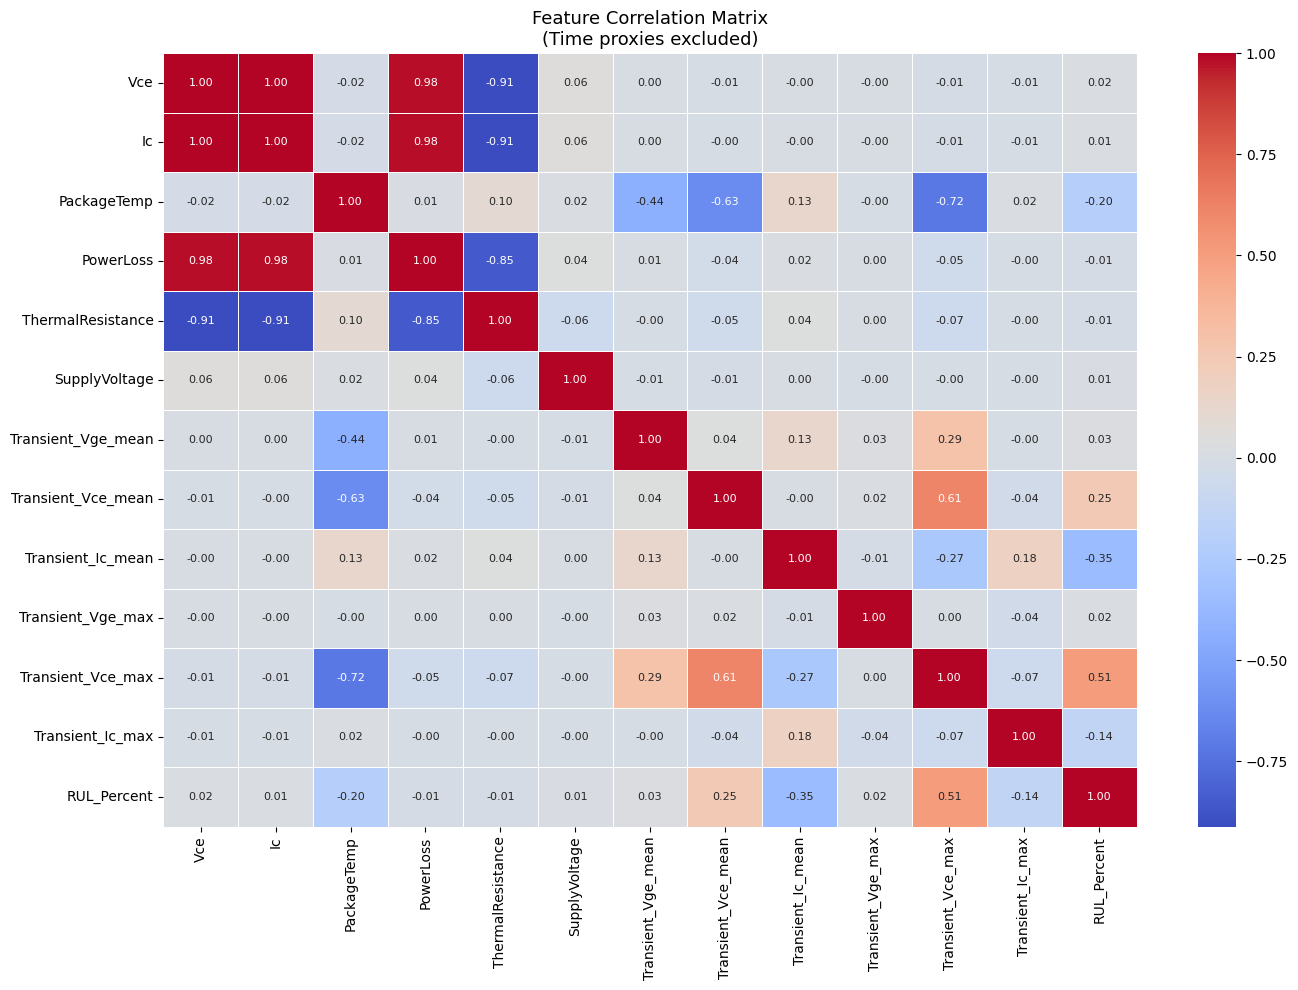

In [29]:
corr_df = df[FEATURES + ['RUL_Percent']].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Feature Correlation Matrix\n(Time proxies excluded)', fontsize=13)
plt.tight_layout()
plt.show()

---
## Best Model — Predicted vs Actual RUL

Best model: 12. Gradient Boosting
Test R²   : 0.9561
RMSE      : 6.8734


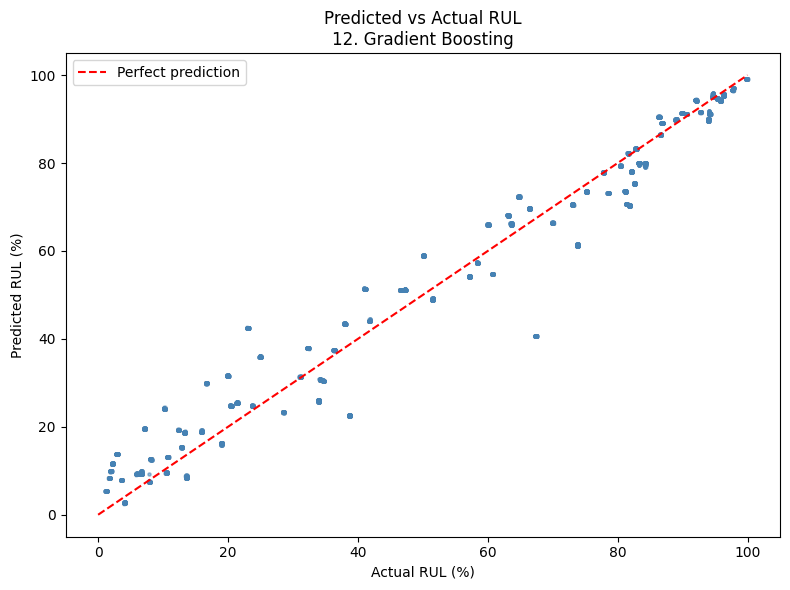

In [30]:
best_model_name = results_df.iloc[0]['Model']
print(f'Best model: {best_model_name}')
print(f'Test R²   : {results_df.iloc[0]["Test R²"]}')
print(f'RMSE      : {results_df.iloc[0]["RMSE"]}')

# Repredict with GB (expected best) for plot
y_best_pred = gb_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_best_pred, alpha=0.3, s=5, color='steelblue')
plt.plot([0,100],[0,100], 'r--', label='Perfect prediction')
plt.xlabel('Actual RUL (%)')
plt.ylabel('Predicted RUL (%)')
plt.title(f'Predicted vs Actual RUL\n{best_model_name}')
plt.legend()
plt.tight_layout()
plt.show()